### Generic reactor parameters

In [1]:
from pathlib import Path
import sys

# Add notebook directory so reactor_parameters can be found
_cwd = Path.cwd().resolve()
_candidates = [_cwd, *_cwd.parents]
_nb_dir = next((p for p in _candidates if (p / "reactor_parameters.py").is_file()), None)
if _nb_dir is not None and str(_nb_dir) not in sys.path:
    sys.path.insert(0, str(_nb_dir))

import numpy as np
import matplotlib.pyplot as plt

from reactor_parameters import *


In [2]:
T_DHe3 = 70 # keV
V_DHe3 = 354 # m^3

# DHe3 with T accumulation in storage

In [3]:
species_params_dhe3 = {
    "D": {
        "f_0": 0.5,
        "tau_p": tau_p_T,
        "tau_ifc": 4.0 * 3600.0,
        "tau_ofc": np.inf,
        "N_stor_min": 0.0,
        "Ndot_max": np.inf,
        "inject_from_storage": False,
        "N_ofc_0": float(SPECIES_DEFAULTS["D"]["N_ofc_0"]),
        "N_ifc_0": float(SPECIES_DEFAULTS["D"]["N_ifc_0"]),
        "N_stor_0": float(SPECIES_DEFAULTS["D"]["N_stor_0"]),
        "enable_plasma_channel": True,
    },
    "T": {
        "f_0": 0.0,
        "tau_p": tau_p_T,
        "tau_ifc": 4.0 * 3600.0,
        "tau_ofc": 2.0 * 3600.0,
        "N_stor_min": 0.001 / species_mass["T"],
        "Ndot_max": np.inf,
        "inject_from_storage": False,
        "N_ofc_0": 0,
        "N_ifc_0": 0,
        "N_stor_0": 0,
        "enable_plasma_channel": True,
    },
    "He3": {
        "f_0": 0.5,
        "tau_p": tau_p_T,
        "tau_ifc": 4.0 * 3600.0,
        "tau_ofc": np.inf,
        "N_stor_min": 0.0,
        "Ndot_max": np.inf,
        "inject_from_storage": False,
        "N_ofc_0": 0,
        "N_ifc_0": 0,
        "N_stor_0": 0,
        "enable_plasma_channel": True,
    },
    "He4": {
        "f_0": 0.0,
        "tau_p": tau_p_T,
        "tau_ifc": 4.0 * 3600.0,
        "tau_ofc": np.inf,
        "N_stor_min": 0.0,
        "Ndot_max": np.inf,
        "inject_from_storage": True,
        "N_ofc_0": 0,
        "N_ifc_0": 0,
        "N_stor_0": 0,
        "enable_plasma_channel": True,
    },
}


In [4]:
injection_mode_dhe3 = {"D": "auto", "T": "off", "He3": "auto", "He4": "off"}

species_params = {
    sp: {
        "tau_p": float(species_params_dhe3[sp]["tau_p"]),
        "lambda_decay": float(species_params_dhe3[sp].get("lambda_decay", SPECIES_DEFAULTS[sp]["lambda_decay"])),
        "tau_ifc": float(species_params_dhe3[sp]["tau_ifc"]),
        "tau_ofc": float(species_params_dhe3[sp]["tau_ofc"]),
        "N_stor_min": float(species_params_dhe3[sp]["N_stor_min"]),
        "Ndot_max": float(species_params_dhe3[sp]["Ndot_max"]),
        "inject_from_storage": bool(species_params_dhe3[sp]["inject_from_storage"]),
        "injection_mode": str(species_params_dhe3[sp].get("injection_mode", injection_mode_dhe3[sp])),
        "enable_plasma_channel": bool(species_params_dhe3[sp]["enable_plasma_channel"]),
    }
    for sp in SPECIES
}

initial_conditions = {
    sp: {
        "f_0": float(species_params_dhe3[sp]["f_0"]),
        "N_ofc_0": float(species_params_dhe3[sp]["N_ofc_0"]),
        "N_ifc_0": float(species_params_dhe3[sp]["N_ifc_0"]),
        "N_stor_0": float(species_params_dhe3[sp]["N_stor_0"]),
    }
    for sp in SPECIES
}
reactivities_dhe3 = compute_reactivities_from_functions(float(T_DHe3))
injection_mix_weights_dhe3 = {"D": 1.0, "He3": 1.0}

### Solve

In [5]:
res_dhe3 = solve_multispecies_ode_system(
    V_plasma=float(V_DHe3),
    T_i=float(T_DHe3),
    n_tot=float(n_tot),
    species_params=species_params,
    initial_conditions=initial_conditions,
    TBR_DT=0,
    TBR_DDn=0,
    max_simulation_time=float(10 * 24 * 3600),
    vector_length=int(vector_length),
    reactivities=reactivities_dhe3,
    injection_mix_weights=injection_mix_weights_dhe3,
)

### plot

In [6]:
t_ref = np.asarray(res_dhe3["t"], dtype=float)
n_D = np.maximum(np.asarray(res_dhe3.get("n_D", np.zeros_like(t_ref)), dtype=float), 0.0)
n_T = np.maximum(np.asarray(res_dhe3.get("n_T", np.zeros_like(t_ref)), dtype=float), 0.0)
n_He3 = np.maximum(np.asarray(res_dhe3.get("n_He3", np.zeros_like(t_ref)), dtype=float), 0.0)

(
    P_DDn,
    P_DDp,
    P_DT,
    P_DHe3,
    P_TT,
    P_He3He3,
    P_THe3_ch1,
    P_THe3_ch2,
    P_THe3_ch3,
    P_DT_eq,
) = compute_fusion_power_profiles_numba(
    n_D,
    n_T,
    n_He3,
    float(n_tot),
    float(V_DHe3),
    float(reactivities_dhe3["sigmav_DD_p"]),
    float(reactivities_dhe3["sigmav_DD_n"]),
    float(reactivities_dhe3["sigmav_DT"]),
    float(reactivities_dhe3["sigmav_DHe3"]),
    float(reactivities_dhe3["sigmav_TT"]),
    float(reactivities_dhe3["sigmav_He3He3"]),
    float(reactivities_dhe3["sigmav_THe3_ch1"]),
    float(reactivities_dhe3["sigmav_THe3_ch2"]),
    float(reactivities_dhe3["sigmav_THe3_ch3"]),
)

P_fusion_total = P_DDn + P_DDp + P_DT + P_DHe3 + P_TT + P_He3He3 + P_THe3_ch1 + P_THe3_ch2 + P_THe3_ch3
P_DDn = np.asarray(P_DDn, dtype=float)
P_DDp = np.asarray(P_DDp, dtype=float)
P_DT = np.asarray(P_DT, dtype=float)
P_DHe3 = np.asarray(P_DHe3, dtype=float)
P_TT = np.asarray(P_TT, dtype=float)
P_He3He3 = np.asarray(P_He3He3, dtype=float)
P_THe3_ch1 = np.asarray(P_THe3_ch1, dtype=float)
P_THe3_ch2 = np.asarray(P_THe3_ch2, dtype=float)
P_THe3_ch3 = np.asarray(P_THe3_ch3, dtype=float)
P_DT_eq = np.asarray(P_DT_eq, dtype=float)
P_fusion_total = np.asarray(P_fusion_total, dtype=float)


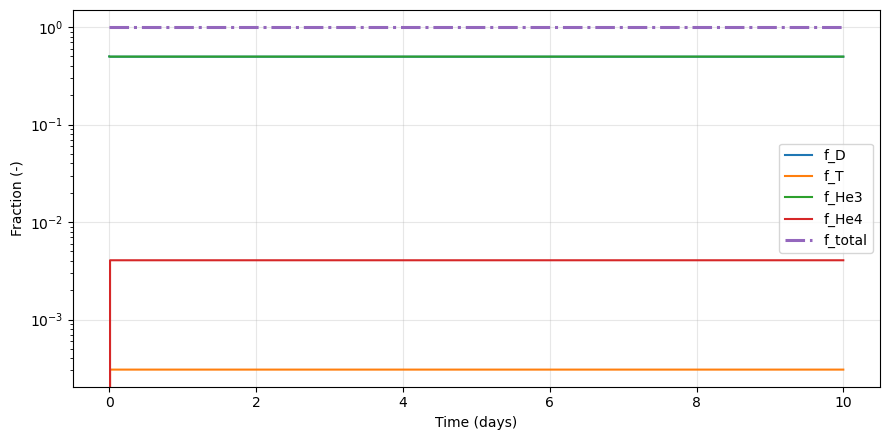

In [7]:
# Plasma fractions
fig, ax = plt.subplots(1, 1, figsize=(9, 4.5))
t_days = np.asarray(res_dhe3["t"], dtype=float) / 86400.0
for sp in SPECIES:
    key = f"n_{sp}"
    if key in res_dhe3:
        ax.plot(t_days, np.asarray(res_dhe3[key], dtype=float) / n_tot, label=f"f_{sp}")
total = np.zeros_like(t_days, dtype=float)
for sp in SPECIES:
    key = f"n_{sp}"
    if key in res_dhe3:
        total = total + np.asarray(res_dhe3[key], dtype=float)
ax.plot(t_days, total / n_tot, lw=2.2, ls='-.', label="f_total")
ax.set_xlabel("Time (days)")
ax.set_ylabel("Fraction (-)")
ax.set_yscale("log")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


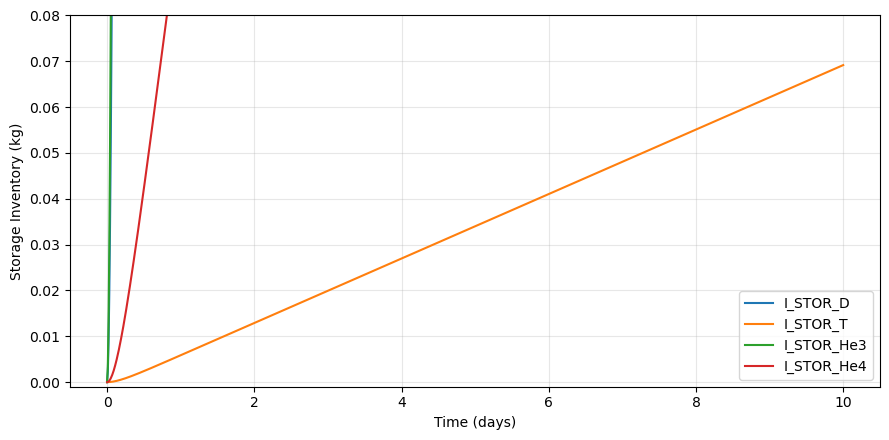

In [8]:
# Storage inventories
fig, ax = plt.subplots(1, 1, figsize=(9, 4.5))
t_days = np.asarray(res_dhe3["t"], dtype=float) / 86400.0
for sp in SPECIES:
    key = f"N_stor_{sp}"
    if key in res_dhe3:
        ax.plot(t_days, np.asarray(res_dhe3[key], dtype=float) * species_mass[sp], label=f"I_STOR_{sp}")
ax.set_xlabel("Time (days)")
ax.set_ylabel("Storage Inventory (kg)")
ax.set_yscale("linear")
ax.grid(True, alpha=0.3)
ax.set_ylim(-1e-3, 0.08)
ax.legend()
plt.tight_layout()
plt.show()


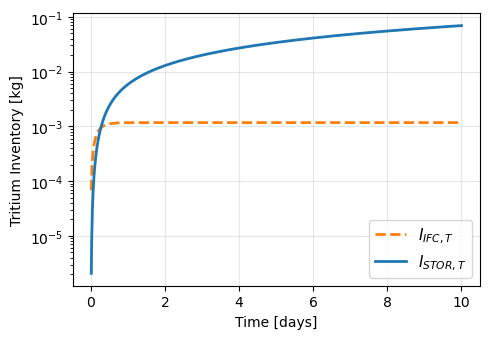

In [9]:
# Tritium inventories
fig, ax = plt.subplots(1, 1, figsize=(5, 3.5))
t_days = np.asarray(res_dhe3["t"], dtype=float) / 86400.0
for fc_type in ["ifc", "stor"]:
    key = f"N_{fc_type}_T"
    I_T = np.asarray(res_dhe3[key], dtype=float) * species_mass["T"]
    I_T_plot = np.where(I_T > 0.0, I_T, np.nan)
    color = "tab:blue" if fc_type == "stor" else "tab:orange"
    linestyle = "-" if fc_type == "stor" else "--"
    ax.plot(t_days, I_T_plot, lw=2.0, label=rf"$I_{{{fc_type.upper()},T}}$", color=color, linestyle=linestyle)
ax.set_xlabel("Time [days]")
ax.set_ylabel("Tritium Inventory [kg]")
ax.set_yscale("log")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()


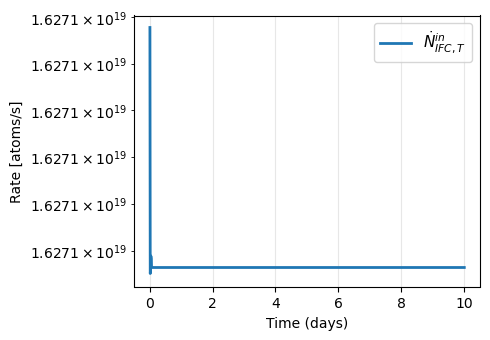

In [10]:
# Tritium arrival rate to IFC
t_days = np.asarray(res_dhe3["t"], dtype=float) / 86400.0
tau_p_T_local = float(species_params["T"]["tau_p"])
tau_ofc_T_local = float(species_params["T"]["tau_ofc"])

N_ifc_in_T = np.maximum(np.asarray(res_dhe3["n_T"], dtype=float), 0.0) * float(V_DHe3) / tau_p_T_local
if np.isfinite(tau_ofc_T_local) and tau_ofc_T_local > 0.0:
    N_ifc_in_T = N_ifc_in_T + np.maximum(np.asarray(res_dhe3["N_ofc_T"], dtype=float), 0.0) / tau_ofc_T_local

N_ifc_in_T_plot = np.where(N_ifc_in_T > 0.0, N_ifc_in_T, np.nan)

fig, ax = plt.subplots(1, 1, figsize=(5, 3.5))
ax.plot(t_days, N_ifc_in_T_plot, lw=2.0, label=r"$\dot{N}^{in}_{IFC,T}$")
ax.set_xlabel("Time (days)")
ax.set_ylabel("Rate [atoms/s]")
ax.set_yscale("log")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()


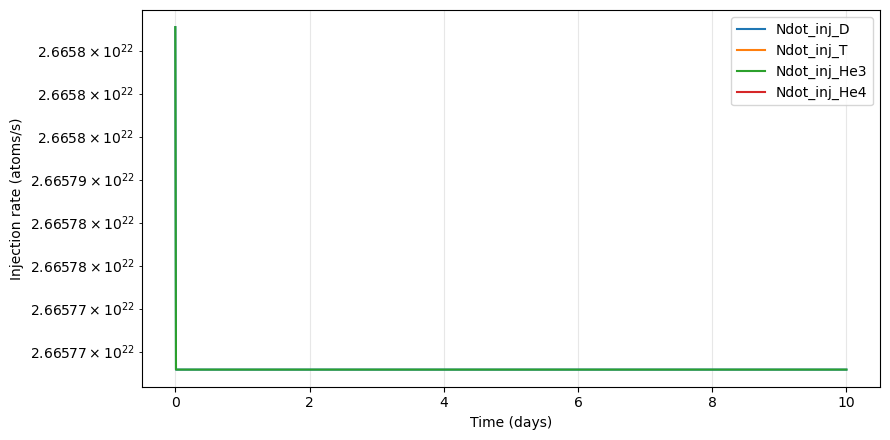

In [11]:
# Injection rates
fig, ax = plt.subplots(1, 1, figsize=(9, 4.5))
t_days = np.asarray(res_dhe3["t"], dtype=float) / 86400.0
for sp in SPECIES:
    key = f"Ndot_inj_{sp}"
    if key in res_dhe3:
        ax.plot(t_days, np.asarray(res_dhe3[key], dtype=float), label=f"Ndot_inj_{sp}")
ax.set_xlabel("Time (days)")
ax.set_ylabel("Injection rate (atoms/s)")
ax.set_yscale("log")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


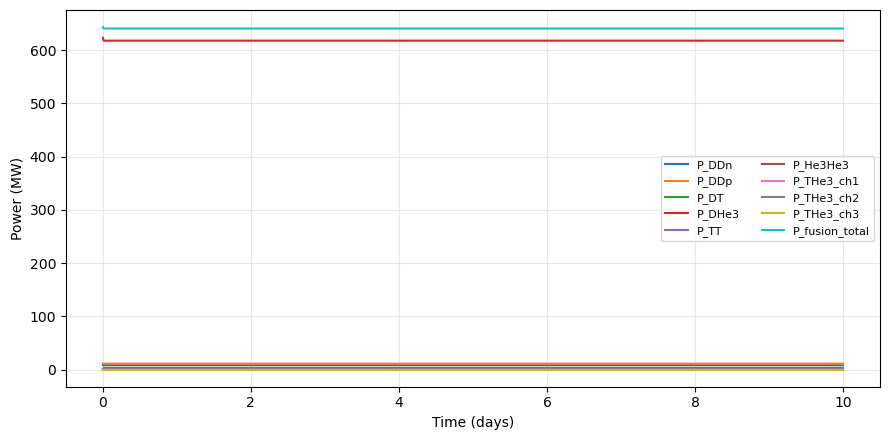

Final fusion power contributions (MW):
P_DDn: 8.1990 MW
P_DDp: 11.2066 MW
P_DT: 3.0579 MW
P_DHe3: 617.9035 MW
P_TT: 0.0000 MW
P_He3He3: 0.4058 MW
P_THe3_ch1: 0.0010 MW
P_THe3_ch2: 0.0007 MW
P_THe3_ch3: 0.0000 MW
P_fusion_total: 640.7744 MW


In [12]:
# Fusion powers
fig, ax = plt.subplots(1, 1, figsize=(9, 4.5))
t_days = np.asarray(res_dhe3["t"], dtype=float) / 86400.0
reaction_series = [
    ("P_DDn", P_DDn),
    ("P_DDp", P_DDp),
    ("P_DT", P_DT),
    ("P_DHe3", P_DHe3),
    ("P_TT", P_TT),
    ("P_He3He3", P_He3He3),
    ("P_THe3_ch1", P_THe3_ch1),
    ("P_THe3_ch2", P_THe3_ch2),
    ("P_THe3_ch3", P_THe3_ch3),
    ("P_fusion_total", P_fusion_total),
]
for label, series in reaction_series:
    ax.plot(t_days, np.asarray(series, dtype=float) * 1.0e-6, label=label)
ax.set_xlabel("Time (days)")
ax.set_ylabel("Power (MW)")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()


print("Final fusion power contributions (MW):")
for label, series in reaction_series:
    print(f"{label}: {series[-1] * 1.0e-6:.4f} MW")